In [14]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/processed/cleaned_data.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [2]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [4]:
#creating RFM table
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice" : "nunique",
    "TotalPrice": "sum"
})

In [5]:
#renaming columns
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,524,11,372.86
12347.0,35,7,4441.11
12348.0,71,5,1659.40
12349.0,14,3,3418.19
12350.0,305,1,294.40


In [7]:
#scales data from large numbers to (~ -1 to +1 range) same as in model notebook
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [9]:
#applying KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [10]:
rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,66.050623,7.419295,2746.975892
1,455.159319,2.204910,646.314143
2,27.666667,140.952381,102680.557143


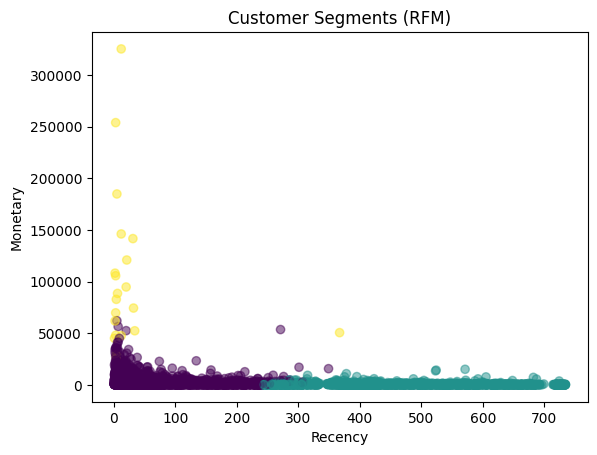

In [16]:
plt.scatter(rfm["Recency"], rfm["Monetary"], c=rfm["Cluster"], alpha=0.5)
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Customer Segments (RFM)")
plt.show()

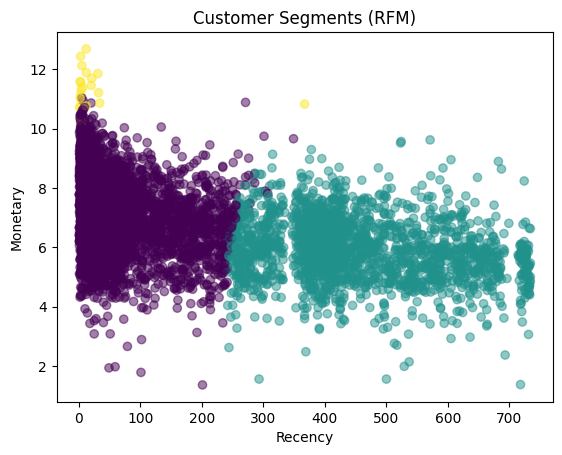

In [17]:
plt.scatter(rfm["Recency"], np.log1p(rfm["Monetary"]), c=rfm["Cluster"], alpha=0.5)
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Customer Segments (RFM)")
plt.show()

In [19]:
rfm.to_csv("../data/processed/rfm_data.csv", index=True)